# Customer Analysis — Online Retail
### Final Compiled Notebook | RFM + KMeans + SVM + Decision Tree + Logistic Regression

In [2]:
from google.colab import files
uploaded = files.upload()

## Step 1 — Load & Clean Data

In [3]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

# Load data
df = pd.read_excel('Online Retail.xlsx')
print(f"Shape: {df.shape}")
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Fix Description column
df['Description'] = df['Description'].fillna('Unknown Product')
df['Description'] = df['Description'].replace('?', 'Unknown Product')

# Convert CustomerID to string and remove NaN customers
df['CustomerID'] = df['CustomerID'].astype(str)
df = df[df['CustomerID'] != 'nan']

# Parse InvoiceDate
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format="%m/%d/%Y %H:%M")
df['InvoiceDate'] = df['InvoiceDate'].dt.date

# Check cancelled invoices
cancelled = df[df["InvoiceNo"].astype(str).str.startswith("C")].shape
print(f"Cancelled invoices: {cancelled}")

# Remove negatives and duplicates
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
df = df.drop_duplicates()

# Date features
df['Year']    = pd.to_datetime(df['InvoiceDate']).dt.year
df['Month']   = pd.to_datetime(df['InvoiceDate']).dt.month
df['Day']     = pd.to_datetime(df['InvoiceDate']).dt.day
df['DayName'] = pd.to_datetime(df['InvoiceDate']).dt.day_name()

print(f"Clean shape: {df.shape}")
print(f"Nulls:\n{df.isnull().sum()}")
df.head()

Cancelled invoices: (8905, 8)
Clean shape: (392691, 13)
Nulls:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
Year           0
Month          0
Day            0
DayName        0
dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,Day,DayName
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850.0,United Kingdom,15.30,2010,12,1,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850.0,United Kingdom,22.00,2010,12,1,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday


In [5]:
# Save cleaned data
df.to_csv('cleaned_online_retail.csv', index=False)
print("Saved: cleaned_online_retail.csv")

Saved: cleaned_online_retail.csv


## Step 2 — RFM Analysis

In [6]:
reference_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo'  : 'count',
    'TotalAmount': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

print(f"RFM shape: {rfm.shape}")
rfm.head()

RFM shape: (4338, 3)


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,18,73,1757.55
12350.0,310,17,334.40


## Step 3 — Exploratory Data Analysis

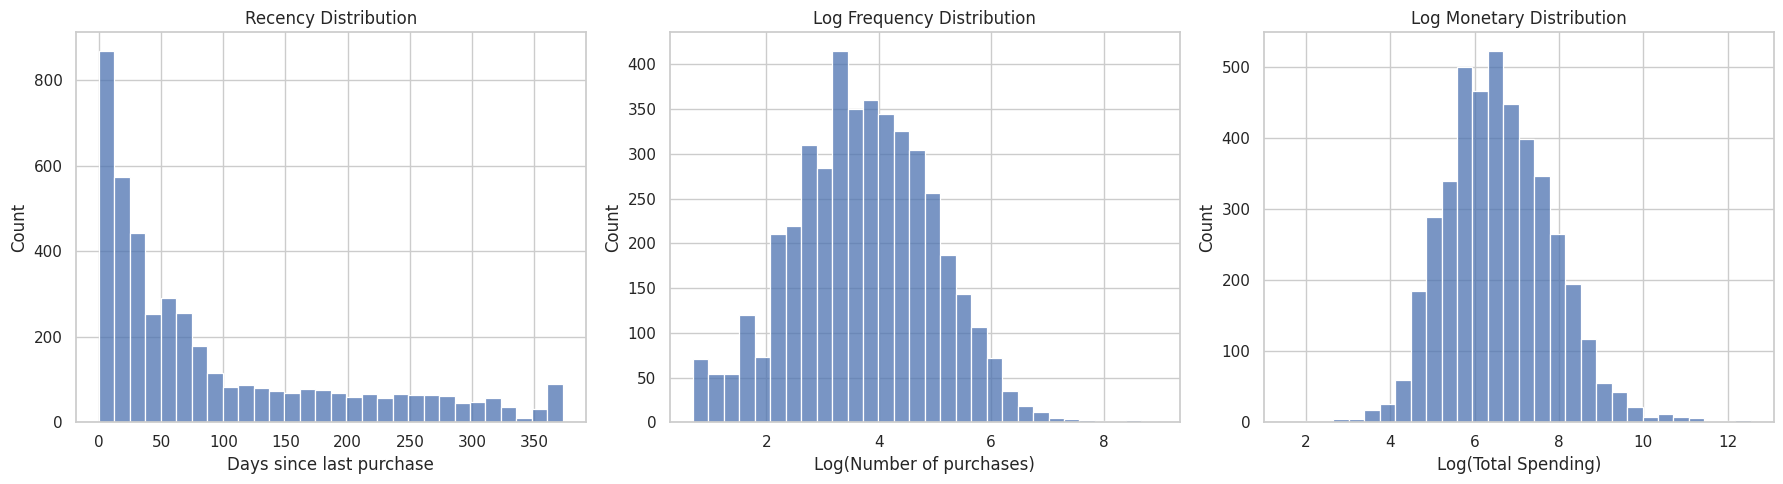

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], bins=30, ax=axes[0])
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days since last purchase")

sns.histplot(np.log1p(rfm['Frequency']), bins=30, ax=axes[1])
axes[1].set_title("Log Frequency Distribution")
axes[1].set_xlabel("Log(Number of purchases)")

sns.histplot(np.log1p(rfm['Monetary']), bins=30, ax=axes[2])
axes[2].set_title("Log Monetary Distribution")
axes[2].set_xlabel("Log(Total Spending)")

plt.tight_layout()
plt.show()

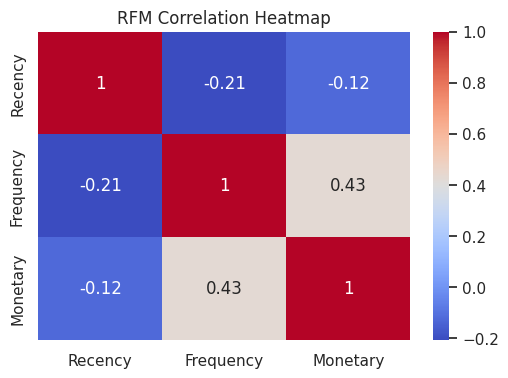

In [8]:
# Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(rfm[['Recency','Frequency','Monetary']].corr(), annot=True, cmap='coolwarm')
plt.title("RFM Correlation Heatmap")
plt.show()

## Step 4 — Preprocessing (Log Transform + Scale)

In [9]:
from sklearn.preprocessing import StandardScaler

# Log transform to handle skewness
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])

# Scale
scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled_array, columns=['Recency', 'Frequency', 'Monetary'], index=rfm.index)

print("Log-transformed and scaled successfully!")
rfm_scaled.head()

Log-transformed and scaled successfully!


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.435416,-2.438203,3.707717
12347.0,-1.953393,1.188986,1.414904
12348.0,0.382865,-0.211465,0.720024
12349.0,-0.619183,0.461819,0.702287
12350.0,1.401368,-0.673555,-0.614514


## Model 1 — KMeans Clustering

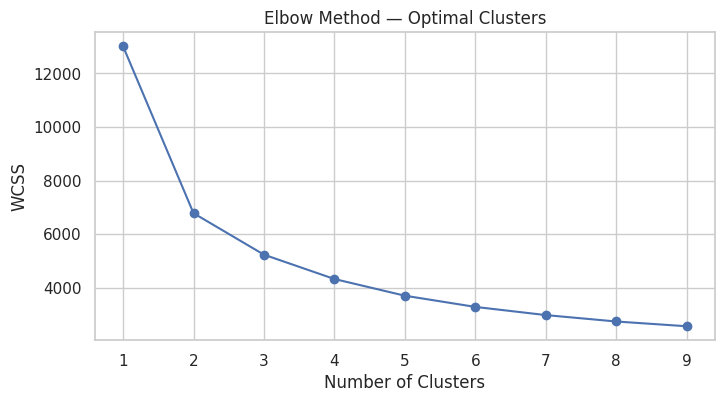

In [10]:
from sklearn.cluster import KMeans

# Elbow method
wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 10), wcss, marker='o')
plt.title('Elbow Method — Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [11]:
# Fit KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("Cluster Summary:")
print(rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean())

Cluster Summary:
            Recency   Frequency     Monetary
Cluster                                     
0         65.416074   64.410060  1163.639657
1        172.078659   15.381044   300.076242
2         13.375783  262.034447  6569.404812


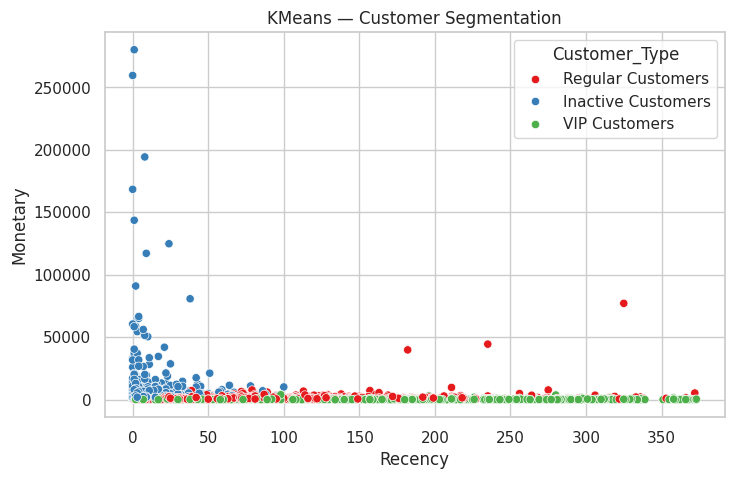

Customer_Type
Regular Customers     1829
VIP Customers         1551
Inactive Customers     958
Name: count, dtype: int64


In [12]:
# Label clusters based on cluster summary
def label_customer(row):
    if row['Cluster'] == 0:
        return 'Regular Customers'
    elif row['Cluster'] == 1:
        return 'VIP Customers'
    else:
        return 'Inactive Customers'

rfm['Customer_Type'] = rfm.apply(label_customer, axis=1)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Customer_Type', palette='Set1')
plt.title('KMeans — Customer Segmentation')
plt.show()

print(rfm['Customer_Type'].value_counts())

## Model 2 — SVM Classification

In [13]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import DecisionBoundaryDisplay

# Target: high vs regular based on RFM score
rfm['Score'] = (
    pd.qcut(rfm['Recency'],  3, labels=[3,2,1]).astype(int) +
    pd.qcut(rfm['Frequency'],3, labels=[1,2,3]).astype(int) +
    pd.qcut(rfm['Monetary'], 3, labels=[1,2,3]).astype(int)
)
rfm['Segment'] = rfm['Score'].apply(lambda x: 1 if x >= 7 else 0)

X = rfm_scaled
y = rfm['Segment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.95

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       505
           1       0.94      0.94      0.94       363

    accuracy                           0.95       868
   macro avg       0.95      0.95      0.95       868
weighted avg       0.95      0.95      0.95       868



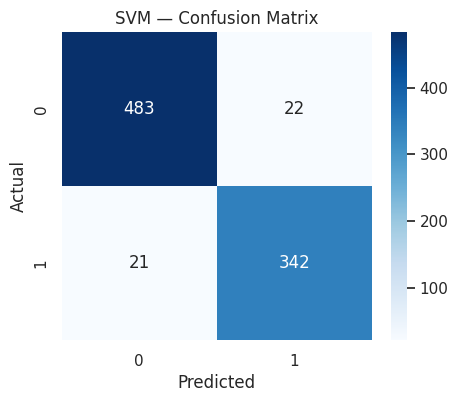

In [14]:
# Confusion Matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("SVM — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

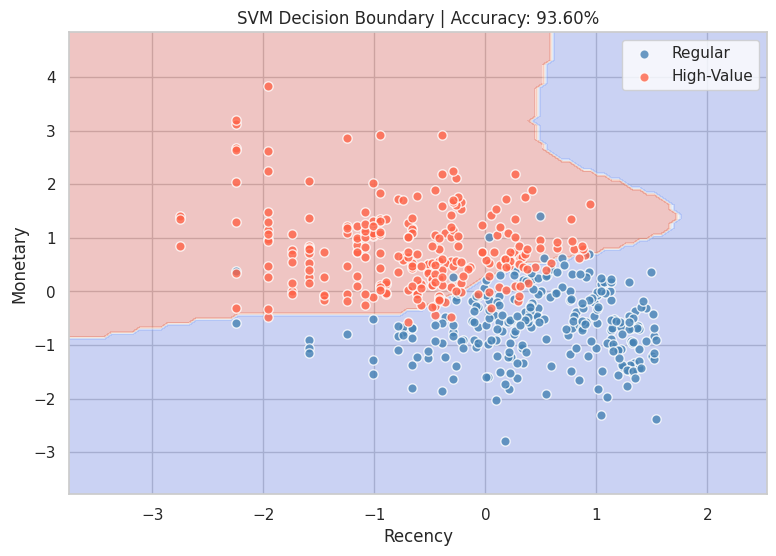

In [15]:
# Decision Boundary (2D — Recency vs Monetary)
X2d   = X_train.values[:, [0, 2]]
y2d   = y_train.values

svm_plot = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_plot.fit(X2d, y2d)

np.random.seed(42)
idx = np.concatenate([
    np.random.choice(np.where(y2d==0)[0], min(250, sum(y2d==0)), replace=False),
    np.random.choice(np.where(y2d==1)[0], min(250, sum(y2d==1)), replace=False)
])
Xp, yp = X2d[idx], y2d[idx]

fig, ax = plt.subplots(figsize=(9, 6))
DecisionBoundaryDisplay.from_estimator(svm_plot, Xp, response_method='predict',
                                        cmap='coolwarm', alpha=0.3, ax=ax)
ax.scatter(Xp[yp==0, 0], Xp[yp==0, 1], c='steelblue', edgecolors='white', s=45, alpha=0.8, label='Regular')
ax.scatter(Xp[yp==1, 0], Xp[yp==1, 1], c='tomato',    edgecolors='white', s=45, alpha=0.8, label='High-Value')
ax.set_xlabel('Recency')
ax.set_ylabel('Monetary')
ax.set_title(f'SVM Decision Boundary | Accuracy: {accuracy_score(yp, svm_plot.predict(Xp)):.2%}')
ax.legend()
plt.show()

## Model 3 — Decision Tree Classification

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# Target: high value based on Monetary median
X_dt = rfm[['Recency', 'Frequency', 'Monetary']]
y_dt = (rfm['Monetary'] > rfm['Monetary'].median()).astype(int)

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y_dt, test_size=0.2, random_state=42
)

dt_model = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
dt_model.fit(X_train_dt, y_train_dt)
y_pred_dt = dt_model.predict(X_test_dt)

print(f"Decision Tree Accuracy: {accuracy_score(y_test_dt, y_pred_dt):.2f}")
print("\nClassification Report:\n", classification_report(y_test_dt, y_pred_dt))

Decision Tree Accuracy: 1.00

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       431
           1       1.00      1.00      1.00       437

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



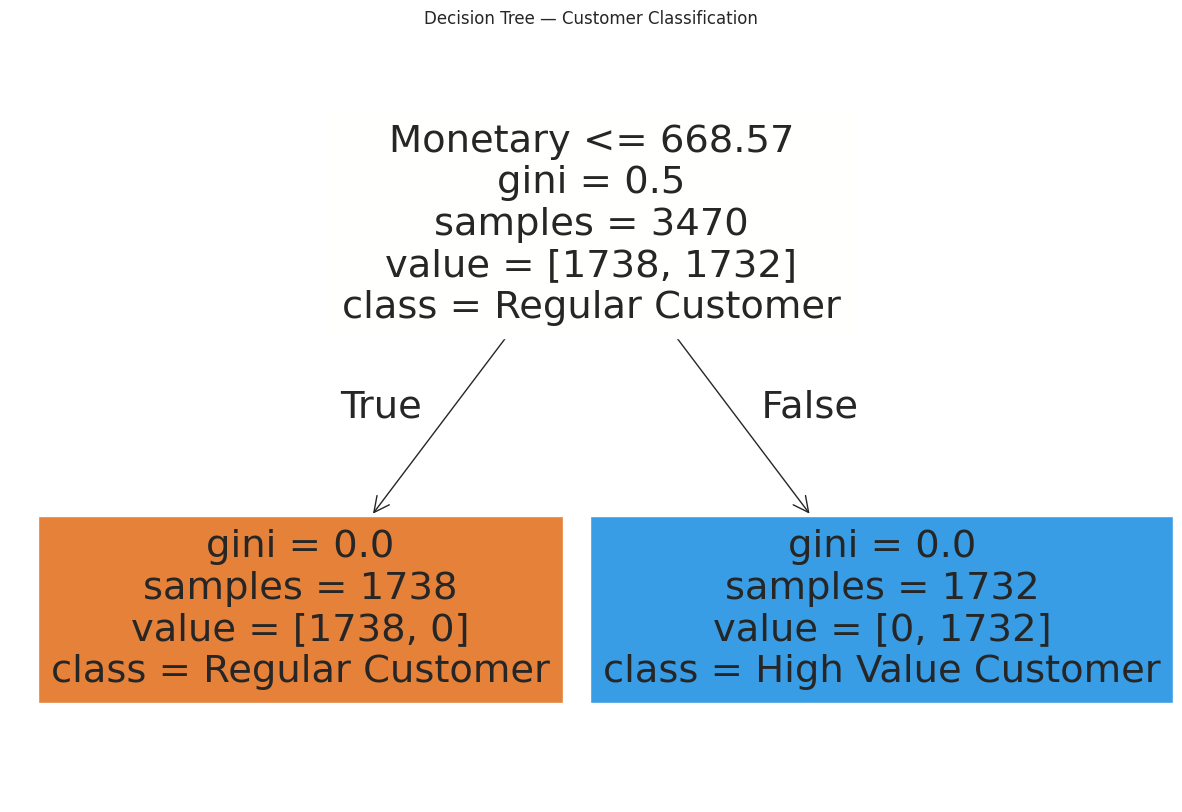

In [17]:
# Plot Decision Tree
plt.figure(figsize=(15, 10))
tree.plot_tree(
    dt_model,
    feature_names=X_dt.columns,
    class_names=['Regular Customer', 'High Value Customer'],
    filled=True
)
plt.title("Decision Tree — Customer Classification")
plt.show()

In [18]:
# Sample prediction
sample = pd.DataFrame([[10, 20, 5000]], columns=['Recency', 'Frequency', 'Monetary'])
pred = dt_model.predict(sample)
label = 'High Value Customer' if pred[0] == 1 else 'Regular Customer'
print(f"Sample prediction: {label}")

Sample prediction: High Value Customer


## Model 4 — Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression

# Target: high vs low frequency based on median
median_frequency = rfm['Frequency'].median()
rfm['Frequency_Segment'] = (rfm['Frequency'] > median_frequency).astype(int)
print(f"Median Frequency: {median_frequency}")
print(rfm['Frequency_Segment'].value_counts())

X_lr = rfm[['Recency', 'Monetary']]
y_lr = rfm['Frequency_Segment']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.3, random_state=42, stratify=y_lr
)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_lr, y_train_lr)
y_pred_lr = lr_model.predict(X_test_lr)

print(f"\nLogistic Regression Accuracy: {accuracy_score(y_test_lr, y_pred_lr):.2f}")
print("\nClassification Report:\n", classification_report(y_test_lr, y_pred_lr))

Median Frequency: 41.0
Frequency_Segment
0    2190
1    2148
Name: count, dtype: int64

Logistic Regression Accuracy: 0.80

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.80       657
           1       0.80      0.81      0.80       645

    accuracy                           0.80      1302
   macro avg       0.80      0.80      0.80      1302
weighted avg       0.80      0.80      0.80      1302



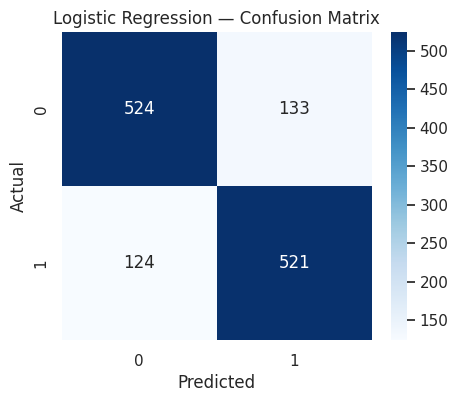

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix for Logistic Regression
plt.figure(figsize=(5, 4))
cm_lr = confusion_matrix(y_test_lr, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

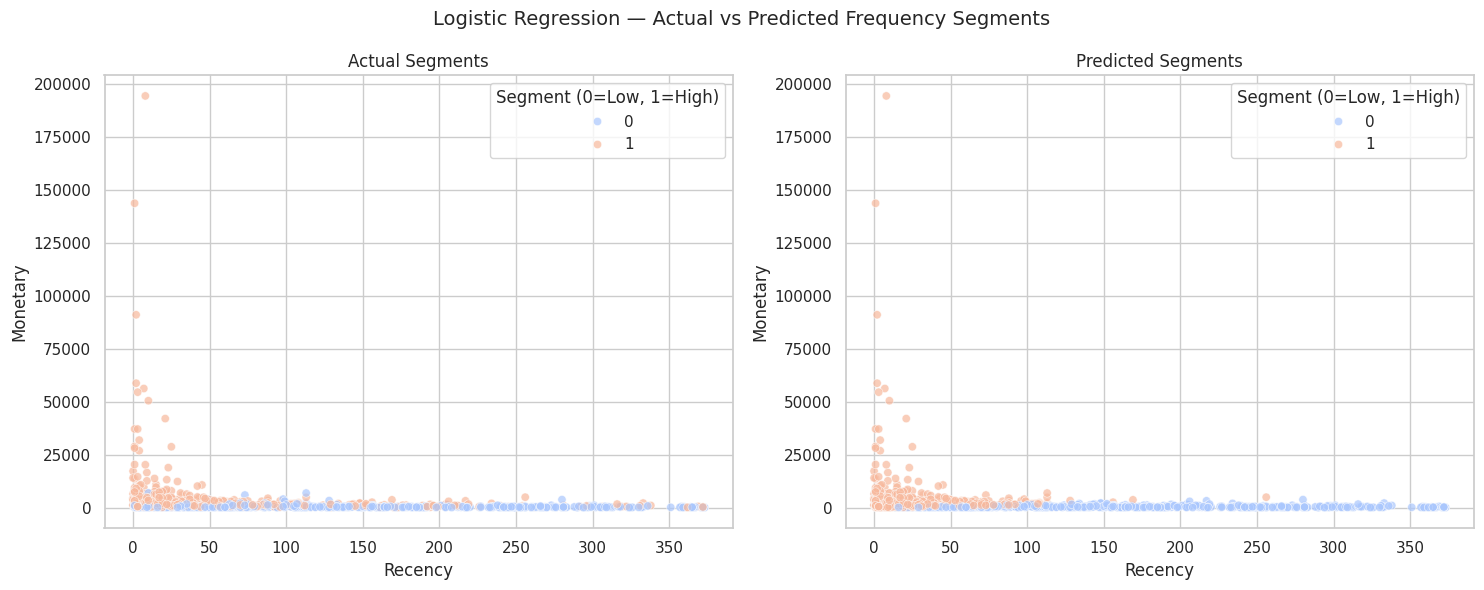

In [20]:
# Actual vs Predicted plot
plot_df = X_test_lr.copy()
plot_df['Actual_Segment']    = y_test_lr.values
plot_df['Predicted_Segment'] = y_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Logistic Regression — Actual vs Predicted Frequency Segments', fontsize=14)

sns.scatterplot(x='Recency', y='Monetary', hue='Actual_Segment',
                data=plot_df, palette='coolwarm', ax=axes[0], alpha=0.7)
axes[0].set_title('Actual Segments')
axes[0].legend(title='Segment (0=Low, 1=High)')

sns.scatterplot(x='Recency', y='Monetary', hue='Predicted_Segment',
                data=plot_df, palette='coolwarm', ax=axes[1], alpha=0.7)
axes[1].set_title('Predicted Segments')
axes[1].legend(title='Segment (0=Low, 1=High)')

plt.tight_layout()
plt.show()

## Model Comparison Summary

In [21]:
results = {
    'Model'   : ['KMeans (Unsupervised)', 'SVM', 'Decision Tree', 'Logistic Regression'],
    'Type'    : ['Clustering', 'Classification', 'Classification', 'Classification'],
    'Accuracy': [
        'N/A (unsupervised)',
        f"{accuracy_score(y_test, y_pred_svm):.2%}",
        f"{accuracy_score(y_test_dt, y_pred_dt):.2%}",
        f"{accuracy_score(y_test_lr, y_pred_lr):.2%}",
    ],
    'Target': [
        'Customer segments',
        'High-Value vs Regular (RFM Score)',
        'High-Value vs Regular (Monetary median)',
        'High vs Low Frequency'
    ]
}

summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))

                Model           Type           Accuracy                                  Target
KMeans (Unsupervised)     Clustering N/A (unsupervised)                       Customer segments
                  SVM Classification             95.05%       High-Value vs Regular (RFM Score)
        Decision Tree Classification            100.00% High-Value vs Regular (Monetary median)
  Logistic Regression Classification             80.26%                   High vs Low Frequency


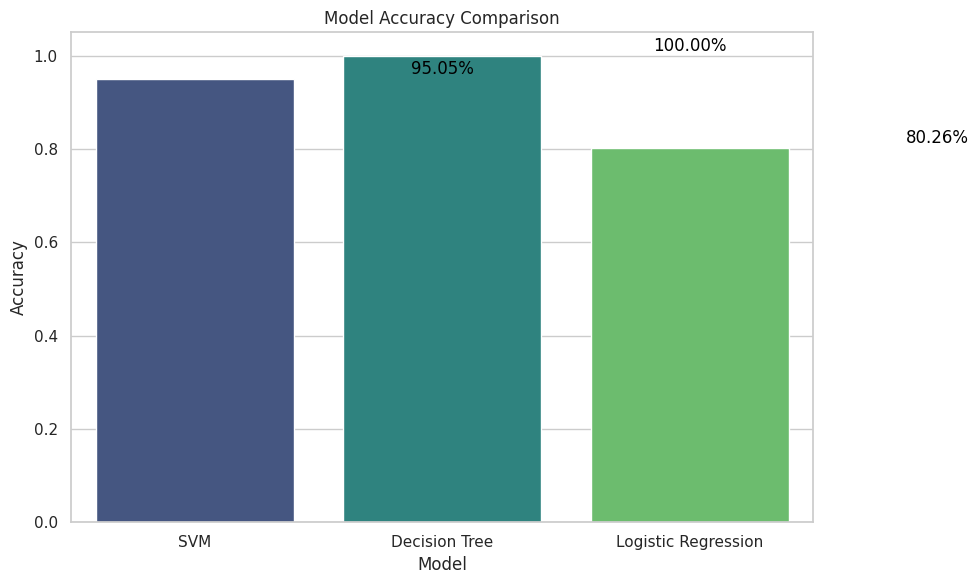

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting (excluding KMeans as it's unsupervised)
plot_data = summary_df[summary_df['Accuracy'] != 'N/A (unsupervised)'].copy()
plot_data['Accuracy_Value'] = plot_data['Accuracy'].str.replace('%', '').astype(float) / 100

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy_Value', data=plot_data, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05) # Set y-axis limit from 0 to 1.05 for better visualization

# Add accuracy percentages on top of the bars
for index, row in plot_data.iterrows():
    plt.text(index, row['Accuracy_Value'] + 0.01, f"{row['Accuracy_Value']:.2%}", color='black', ha='center')

plt.tight_layout()
plt.show()